In [1]:
import numpy as np
import pickle
from scipy.stats import sem
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import CMR_IA as cmr
import scipy as sp
from matplotlib.lines import Line2D
import sys

sys.path.append("../../Modeling/fitting")
from optimization_utils import make_boundary

In [2]:
# plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["font.size"] = 16
SAVEFIG = False
SAVERES = False

## Load Stimuli and Semantic Matrix

In [3]:
with open("simu6a_data/simu6a_design.pkl", "rb") as inp:
    df_study = pickle.load(inp)
    df_test = pickle.load(inp)
df_study = df_study.loc[df_study.session < 100]  # for testing
df_test = df_test.loc[df_test.session < 100]  # for testing

In [4]:
df_study

,study_itemno1,study_itemno2,study_item1,study_item2,list,session
0,1569,1107,VINEGAR,PORCUPINE,0,0
1,30,696,APARTMENT,HEADBAND,0,0
2,1457,1443,THIGH,TECHNICIAN,0,0
3,1331,31,SNACK,APE,0,0
4,1377,1579,STEP,WAIST,0,0
...,...,...,...,...,...,...
25195,1352,239,SPINACH,CAPTAIN,41,99
25196,323,787,CLIMBER,KNOB,41,99
25197,299,1369,CHILD,STALLION,41,99
25198,504,63,DUCK,AWARD,41,99


In [5]:
df_test

,test_itemno,test_item,correct_ans,lag,list,session,order
0,468,DINNER,681,0,0,0,2
1,1579,WAIST,1377,1,0,0,2
2,1331,SNACK,31,2,0,0,1
3,1457,THIGH,1443,3,0,0,1
4,696,HEADBAND,30,4,0,0,2
...,...,...,...,...,...,...,...
25195,63,AWARD,504,1,41,99,2
25196,299,CHILD,1369,2,41,99,1
25197,323,CLIMBER,787,3,41,99,1
25198,239,CAPTAIN,1352,4,41,99,2


In [6]:
sem_mat = np.load("../wordpools/ltp_FR_similarity_matrix.npy")

## Run CMR-IA

In [7]:
# define parameters
params = cmr.make_default_params()
params.update(nitems_in_accumulator=48, use_new_context=True)

# load pso results
_, _, what_to_fit = make_boundary(sim_name="6a")
optim_params = np.loadtxt("simu6a_data/6a_250303_200-200.txt")
for pname, pvalue in zip(what_to_fit, optim_params):
    params[pname] = pvalue
params.update(beta_enc_inpair=0)
params

{'beta_enc': 0.865892,
 'beta_rec': 0.652424,
 'beta_cue': 0.426097,
 'beta_rec_post': 0.172886,
 'beta_distract': 0.067423,
 'beta_enc_inpair': 0,
 'phi_s': 5.980683,
 'phi_d': 0.036111,
 's_cf': 0.498767,
 's_fc': 0.059528,
 'kappa': 0.359133,
 'eta': 0.038905,
 'omega': 5.349761,
 'alpha': 0.649977,
 'lamb': 0.070978,
 'c_thresh': 0.150601,
 'c_thresh_itm': 0.5,
 'c_thresh_assoc': 0.5,
 'd_assoc': 0,
 'rec_time_limit': 60000.0,
 'dt': 10,
 'nitems_in_accumulator': 48,
 'max_recalls': 50,
 'learn_while_retrieving': False,
 'use_new_context': True,
 'psi_s': 0,
 'psi_c': 1,
 'c_s': 0,
 'thresh_sigma': 0,
 'ban_recall': None,
 'use_var_enc': False,
 'var_enc_p': None,
 'bad_enc_ratio': None,
 'recog_slope': 1,
 'use_flexible_thresh': False,
 'thresh_rate': 0,
 'thresh_kernel_len': 10,
 'gamma_fc': 0.18181,
 'gamma_cf': 0.206402}

In [8]:
# # define parameters
# params = cmr.make_default_params()
# params.update(
#     beta_enc=0.7,
#     beta_cue=0.55,
#     beta_distract=0.01,
#     beta_rec_post=0.99,
#     beta_rec=0.5,
#     gamma_fc=0.28,
#     gamma_cf=0.28,
#     s_fc=0.1,
#     s_cf=0.1,
#     c_thresh=0.01,
#     kappa=0.04,
#     lamb=0.02,
#     eta=0.01,
#     alpha=0.9,
#     omega=3,
#     phi_s=0.4,
#     phi_d=1.3,
#     nitems_in_accumulator=48,
#     use_new_context=True,
# )
# params

In [9]:
# run CMR-IA
df_simu, f_in, f_dif = cmr.run_norm_cr_multi_sess(params, df_study, df_test, sem_mat)
df_simu

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [02:14<00:00,  1.35s/it]

CMR Time: 134.95101857185364


,session,list,test_itemno,s_resp,s_rt,csim
0,0,0,468,681,760,0.836555
1,0,0,1579,-1,-1,-1.000000
2,0,0,1331,-1,-1,-1.000000
3,0,0,1457,31,1180,0.221872
4,0,0,696,-1,-1,-1.000000
...,...,...,...,...,...,...
25195,99,41,63,504,2340,0.306589
25196,99,41,299,-1,-1,-1.000000
25197,99,41,323,787,2090,0.206927
25198,99,41,239,-1,-1,-1.000000


In [10]:
# merge to get more info
df_simu = df_simu.merge(df_test, on=["session", "list", "test_itemno"])
df_simu["correct"] = df_simu.s_resp == df_simu.correct_ans
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,lag,order,correct
0,0,0,468,681,760,0.836555,DINNER,681,0,2,True
1,0,0,1579,-1,-1,-1.000000,WAIST,1377,1,2,False
2,0,0,1331,-1,-1,-1.000000,SNACK,31,2,1,False
3,0,0,1457,31,1180,0.221872,THIGH,1443,3,1,False
4,0,0,696,-1,-1,-1.000000,HEADBAND,30,4,2,False
...,...,...,...,...,...,...,...,...,...,...,...
25195,99,41,63,504,2340,0.306589,AWARD,504,1,2,True
25196,99,41,299,-1,-1,-1.000000,CHILD,1369,2,1,False
25197,99,41,323,787,2090,0.206927,CLIMBER,787,3,1,True
25198,99,41,239,-1,-1,-1.000000,CAPTAIN,1352,4,2,False


In [11]:
# merge f_in info, for testing
sessions = np.unique(df_simu.session)
for sess in sessions:
    df_tmp = df_study.loc[df_study.session == sess]
    tmp1 = df_tmp.study_itemno1.to_numpy()
    tmp2 = df_tmp.study_itemno2.to_numpy()
    tmp = np.concatenate((tmp1, tmp2))
    tmp = np.sort(tmp)
    tmp_test = df_simu.loc[df_study.session == sess, "test_itemno"]
    tmp_corr = df_simu.loc[df_study.session == sess, "correct_ans"]
    testid = np.searchsorted(tmp, tmp_test)
    corrid = np.searchsorted(tmp, tmp_corr)

    df_simu.loc[df_simu.session == sess, "corr_fin"] = [f_dif[sess][i][id] for i, id in enumerate(corrid)]
    # df_simu.loc[df_simu.session == sess, 'omean_fin'] = [np.mean(np.delete(f_dif[sess][i], id)) for i, id in corrid]
    df_simu.loc[df_simu.session == sess, "omax_fin"] = [np.max(np.delete(f_dif[sess][i], id)) for i, id in enumerate(corrid)]
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,lag,order,correct,corr_fin,omax_fin
0,0,0,468,681,760,0.836555,DINNER,681,0,2,True,1.191923,0.070418
1,0,0,1579,-1,-1,-1.000000,WAIST,1377,1,2,False,-0.259978,-0.102371
2,0,0,1331,-1,-1,-1.000000,SNACK,31,2,1,False,0.228866,-0.118228
3,0,0,1457,31,1180,0.221872,THIGH,1443,3,1,False,0.000603,0.366197
4,0,0,696,-1,-1,-1.000000,HEADBAND,30,4,2,False,-0.096295,-0.003609
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25195,99,41,63,504,2340,0.306589,AWARD,504,1,2,True,0.030218,-0.277454
25196,99,41,299,-1,-1,-1.000000,CHILD,1369,2,1,False,0.155335,0.012647
25197,99,41,323,787,2090,0.206927,CLIMBER,787,3,1,True,0.293415,0.321013
25198,99,41,239,-1,-1,-1.000000,CAPTAIN,1352,4,2,False,0.084414,0.097904


In [12]:
# if SAVERES:
#     df_simu.to_pickle("simu6a_data/simu6a_result.pkl")

## Analysis

In [13]:
# with open("simu6a_data/simu6a_result.pkl", "rb") as inp:
#     df_simu = pickle.load(inp)

In [14]:
# clean first 2 list
df_simu = df_simu.query("list > 1")
df_simu

,session,list,test_itemno,s_resp,s_rt,csim,test_item,correct_ans,lag,order,correct,corr_fin,omax_fin
12,0,2,887,816,1190,0.249254,MERMAID,816,0,1,True,0.448071,-0.150822
13,0,2,10,1101,2360,0.203089,AGENT,1101,1,1,True,0.202828,-0.363642
14,0,2,1411,-1,-1,-1.000000,SUPPER,1561,2,2,False,-0.305472,-0.048751
15,0,2,959,1104,3670,0.273115,NOTEBOOK,1104,3,2,True,0.172039,-0.168550
16,0,2,1448,-1,-1,-1.000000,TEMPLE,969,4,2,False,0.017223,-0.069202
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25195,99,41,63,504,2340,0.306589,AWARD,504,1,2,True,0.030218,-0.277454
25196,99,41,299,-1,-1,-1.000000,CHILD,1369,2,1,False,0.155335,0.012647
25197,99,41,323,787,2090,0.206927,CLIMBER,787,3,1,True,0.293415,0.321013
25198,99,41,239,-1,-1,-1.000000,CAPTAIN,1352,4,2,False,0.084414,0.097904


### f_IN

In [15]:
df_fin = df_simu.groupby("lag")[["corr_fin", "omax_fin"]].mean().reset_index()
df_fin["dif"] = df_fin["corr_fin"] - df_fin["omax_fin"]
df_fin

,lag,corr_fin,omax_fin,dif
0,0,0.792627,0.083149,0.709478
1,1,0.064818,-0.179626,0.244444
2,2,0.031702,0.033448,-0.001746
3,3,0.060387,0.135105,-0.074718
4,4,0.129246,0.194800,-0.065554
5,5,0.177943,0.238661,-0.060718


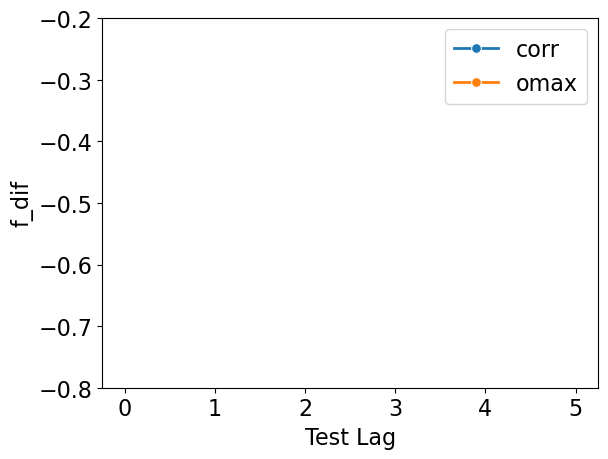

In [16]:
sns.lineplot(data=df_fin, x="lag", y="corr_fin", linewidth=2, marker="o", markersize=7, label="corr")
# sns.lineplot(data=df_fin, x='lag', y='omean_fin', linewidth=2, marker='o', markersize = 7)
sns.lineplot(data=df_fin, x="lag", y="omax_fin", linewidth=2, marker="o", markersize=7, label="omax")
plt.ylim([-0.8, -0.2])
plt.xlabel("Test Lag")
plt.ylabel("f_dif")
plt.show()

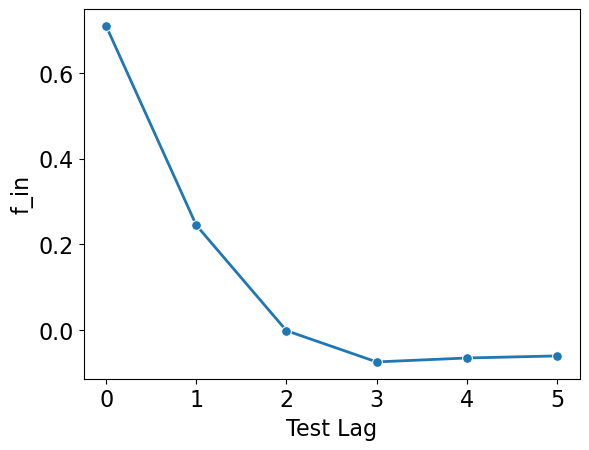

In [17]:
sns.lineplot(data=df_fin, x="lag", y="dif", linewidth=2, marker="o", markersize=7)
# plt.ylim([0,1])
plt.xlabel("Test Lag")
plt.ylabel("f_in")
plt.show()

### Yes rate

In [18]:
# session-wise, calculate correct rate for each condition
df_sess_lag = df_simu.groupby(["session", "lag", "order"]).correct.mean().to_frame(name="correct_rate").reset_index()
df_sess_lag

,session,lag,order,correct_rate
0,0,0,1,1.000000
1,0,0,2,1.000000
2,0,1,1,0.619048
3,0,1,2,0.368421
4,0,2,1,0.150000
...,...,...,...,...
1195,99,3,2,0.062500
1196,99,4,1,0.600000
1197,99,4,2,0.200000
1198,99,5,1,0.687500


In [19]:
# collapse across sessions
df_lag = df_sess_lag.groupby(["lag", "order"]).correct_rate.mean().to_frame(name="correct_rate").reset_index()
df_lag

,lag,order,correct_rate
0,0,1,0.990088
1,0,2,0.998107
2,1,1,0.619876
3,1,2,0.359548
4,2,1,0.336610
5,2,2,0.100866
6,3,1,0.347182
7,3,2,0.063172
8,4,1,0.383651
9,4,2,0.078552


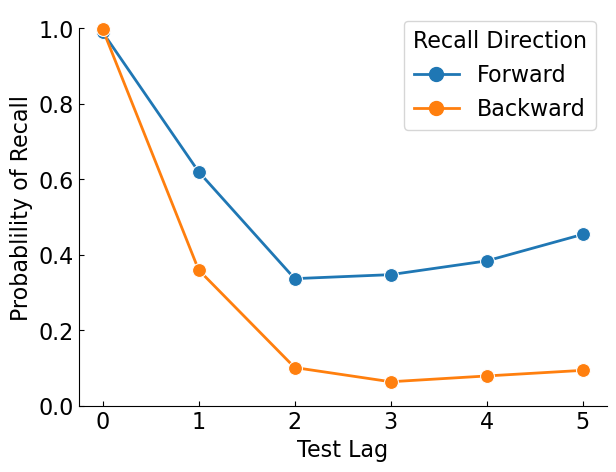

In [20]:
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)

ax.spines["left"].set_bounds(0, 1)
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
sns.lineplot(data=df_lag, x="lag", y="correct_rate", linewidth=2, marker="o", markersize=10, hue="order", palette="tab10")
plt.ylim([0, 1.05])
plt.xlabel("Test Lag")
plt.ylabel("Probablility of Recall")

legend_elements = [
    Line2D([0], [0], color=sns.color_palette()[0], lw=2, marker="o", markersize=10, linestyle="-", label="Forward"),
    Line2D([0], [0], color=sns.color_palette()[1], lw=2, marker="o", markersize=10, linestyle="-", label="Backward"),
]
L = plt.legend(handles=legend_elements, title="Recall Direction", loc="upper right")

if SAVEFIG:
    ax.set(xlabel=None, ylabel=None)
    plt.tick_params(labelleft=False)
    plt.savefig("simu6a_fig/simu6a_recall.pdf")

### Error Check

In [21]:
with open("simu6a_data/simu6a_gt.pkl", "rb") as f:
    fw_gt = pickle.load(f)
    bw_gt = pickle.load(f)

fw = df_lag.query("order == 1").correct_rate.values
bw = df_lag.query("order == 2").correct_rate.values
err = np.power(fw - fw_gt, 2).sum() + np.power(bw - bw_gt, 2).sum()
err

0.2969454609500977

In [22]:
fw, bw

(array([0.9900876 , 0.61987581, 0.33661038, 0.34718218, 0.38365087,
        0.45393273]),
 array([0.99810663, 0.35954832, 0.10086646, 0.06317187, 0.07855195,
        0.09341446]))

## Multiple Tests

In [23]:
betas = [-1, 0, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]

fws, bws, fw_bws = [], [], []
for beta_enc_inpair in betas:

    # run
    params.update(beta_enc_inpair=beta_enc_inpair)
    df_simu, _, _ = cmr.run_norm_cr_multi_sess(params, df_study, df_test, sem_mat)

    # merge to get more info
    df_simu = df_simu.merge(df_test, on=["session", "list", "test_itemno"])
    df_simu["correct"] = df_simu.s_resp == df_simu.correct_ans

    # clean first 2 list
    df_simu = df_simu.query("list > 1")

    # session-wise, calculate correct rate for each condition
    df_sess_lag = df_simu.groupby(["session", "lag", "order"]).correct.mean().to_frame(name="correct_rate").reset_index()

    # collapse across sessions
    df_lag = df_sess_lag.groupby(["lag", "order"]).correct_rate.mean().to_frame(name="correct_rate").reset_index()

    fw = df_lag.query("order == 1").correct_rate.values
    bw = df_lag.query("order == 2").correct_rate.values
    fw_bw = fw - bw
    fws.append(fw)
    bws.append(bw)
    fw_bws.append(fw_bw)

100%|██████████| 100/100 [01:57<00:00,  1.18s/it]


CMR Time: 117.98885130882263


100%|██████████| 100/100 [02:11<00:00,  1.32s/it]


CMR Time: 131.64836978912354


100%|██████████| 100/100 [02:09<00:00,  1.30s/it]


...

CMR Time: 128.81274247169495


100%|██████████| 100/100 [02:06<00:00,  1.26s/it]


CMR Time: 126.10116481781006


100%|██████████| 100/100 [02:05<00:00,  1.26s/it]

CMR Time: 125.96239423751831


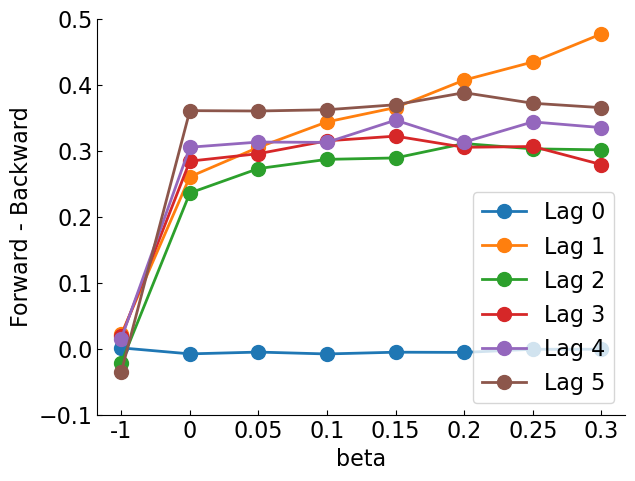

In [27]:
# plot each column of fw_bws
fig, ax = plt.subplots(figsize=(6, 4.5))
fig.subplots_adjust(left=0.1, right=0.98, bottom=0.1, top=0.98)
ax.spines["left"].set_bounds(-0.1, 0.5)
ax.spines[["right", "top"]].set_visible(False)
ax.tick_params(axis="y", direction="in")
ax.tick_params(axis="x", direction="in")
for i in range(6):
    ax.plot(np.array(fw_bws)[:, i], linewidth=2, marker="o", markersize=10, label=f"Lag {i}")
plt.ylim([-0.1, 0.5])
plt.xlabel("beta")
plt.ylabel("Forward - Backward")
plt.xticks(ticks=range(len(betas)), labels=betas)
plt.legend()

In [28]:
fw_bws

[array([ 0.00106659,  0.02175798, -0.02142558,  0.01835784,  0.01526957,
        -0.03544524]),
 array([-0.00801902,  0.26032749,  0.23574392,  0.28401031,  0.30509892,
         0.36051827]),
 array([-0.00530033,  0.30498219,  0.2727527 ,  0.2953083 ,  0.31291713,
         0.35996444]),
 array([-0.00813562,  0.34347629,  0.28668634,  0.3147818 ,  0.31243235,
         0.36188504]),
 array([-0.00547423,  0.36522054,  0.28885125,  0.32188611,  0.34609415,
         0.36945462]),
 array([-0.00580264,  0.40678841,  0.31064226,  0.3049862 ,  0.31275577,
         0.38774901]),
 array([-0.00105228,  0.43421602,  0.30263132,  0.30618836,  0.34348783,
         0.37172933]),
 array([-0.00099759,  0.47668005,  0.30109852,  0.27882404,  0.33480716,
         0.36504198])]